# Example: Sample Portfolio Weights with the Dirichlet Distribution
In this example, we draw random long-only portfolio weight vectors with the Dirichlet distribution, see how the concentration parameter shapes them, and use them to explore the growth-rate mean and variance of the portfolios they define. The point of the exercise is the lecture's warning: sampling explores the simplex, and only when we evaluate an objective for each draw does one weight vector become better than another. Along the way we compute buy-and-hold wealth for a few of the sampled portfolios and watch the weights drift.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * **Draw and interpret Dirichlet weight vectors:** Sample weight vectors on the three-asset simplex for several concentration vectors, check that every draw is a valid long-only allocation, and verify the mean and variance formulas from the lecture against the samples.
> * **Explore portfolio risk and growth across the simplex:** For a five-asset portfolio, compute the growth-rate mean and standard deviation of thousands of random allocations, locate the single-asset corners and the equal-weight portfolio in the cloud, and find the lowest-variance draw.
> * **Compute buy-and-hold wealth and weight drift:** Turn a weight vector and an initial budget into share counts, track portfolio wealth over a year of prices, and see how the fractions of wealth in each asset drift away from the initial weights.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the [`Include.jl`](Include.jl) file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The [`Include.jl`](Include.jl) file sets paths, loads the required external packages, and includes local helper code. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 until December 31, 2024, along with data for several exchange-traded funds and volatility products during that time period. 

Let's load the `original_dataset::Dict{String,DataFrame}` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's use a firm known to have a complete record, `AAPL`, to compute the maximum number of trading days. We save that value in `maximum_number_trading_days::Int64`:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow;

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # Initialize -
    dataset = Dict{String, DataFrame}();

    # Keep complete time series; dictionary iteration order is not guaranteed.
    for (ticker, data) ∈ original_dataset 
        if (nrow(data) == maximum_number_trading_days) # retain tickers with complete histories
            dataset[ticker] = data;
        end
    end
    dataset; # Return
end;

Next, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort; # list of firm "ticker" symbols in alphabetical order

### Constants and Portfolios
Let's specify the constants we will use and the two small portfolios we will explore: three firms for the pictures (a three-asset simplex is a triangle we can draw) and five for the risk-growth cloud. Check that every ticker is in the cleaned dataset:

In [6]:
Δt = (1/252); # time step (1 trading day, in years)
my_tickers_3 = ["AAPL", "JNJ", "XOM"]; # three-asset portfolio for the simplex pictures
my_tickers_5 = ["AAPL", "JNJ", "XOM", "JPM", "NVDA"]; # five-asset portfolio for the risk-growth cloud
number_of_samples = 5000; # Dirichlet draws per experiment
for t ∈ my_tickers_5
    @assert haskey(dataset, t) "ticker $(t) is not in the cleaned dataset"
end
(my_tickers_3 = my_tickers_3, my_tickers_5 = my_tickers_5, number_of_samples = number_of_samples)
Random.seed!(5660); # make the Dirichlet draws reproducible

___

## Task 1: Draw Weights on the Three-Asset Simplex
In this task, we draw and compare four Dirichlet samples on a three-asset simplex so the concentration parameters have a visible geometric meaning.

A long-only, fully invested weight vector for $M=3$ assets satisfies $w_{i}\geq0$ and $w_{1}+w_{2}+w_{3}=1$, so it lives on a triangle. Because $w_{3}=1-w_{1}-w_{2}$ (the complement, proportional to the distance from the diagonal edge), we can draw the triangle in the $(w_{1},w_{2})$ plane: the corners $(1,0)$, $(0,1)$, and $(0,0)$ are the single-asset portfolios, and the center $(1/3,1/3)$ is equal weights. Let's draw `number_of_samples` weight vectors from [the `Dirichlet` distribution](https://juliastats.org/Distributions.jl/stable/multivariate/#Distributions.Dirichlet) exported by [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for four concentration vectors: symmetric and small ($\alpha_{i}=0.5$), uniform on the simplex ($\alpha_{i}=1$), symmetric and large ($\alpha_{i}=5$), and tilted toward the first asset ($\boldsymbol{\alpha}=(5,1,1)$). We store the draws in the `dirichlet_samples::Dict{String,Matrix{Float64}}` variable, one column per draw:

In [7]:
dirichlet_samples = let
    concentrations = Dict("α = (0.5, 0.5, 0.5)" => [0.5, 0.5, 0.5], "α = (1, 1, 1)" => [1.0, 1.0, 1.0],
        "α = (5, 5, 5)" => [5.0, 5.0, 5.0], "α = (5, 1, 1)" => [5.0, 1.0, 1.0]);
    samples = Dict{String, Matrix{Float64}}();
    for (label, α) ∈ concentrations
        d = Dirichlet(α);
        W = rand(d, number_of_samples); # 3 × number_of_samples, one weight vector per column
        @assert all(W .> 0) && all(isapprox.(sum(W, dims=1), 1.0; atol=1e-12)) # valid long-only allocations
        samples[label] = W;
    end
    samples
end;
keys(dirichlet_samples)

KeySet for a Dict{String, Matrix{Float64}} with 4 entries. Keys:
  "α = (5, 1, 1)"
  "α = (1, 1, 1)"
  "α = (0.5, 0.5, 0.5)"
  "α = (5, 5, 5)"

Every draw is strictly positive and sums to one, as the lecture said. Let's plot the four clouds in the $(w_{1},w_{2})$ plane, with the triangle boundary drawn in; the third weight is the complement $1-w_{1}-w_{2}$:

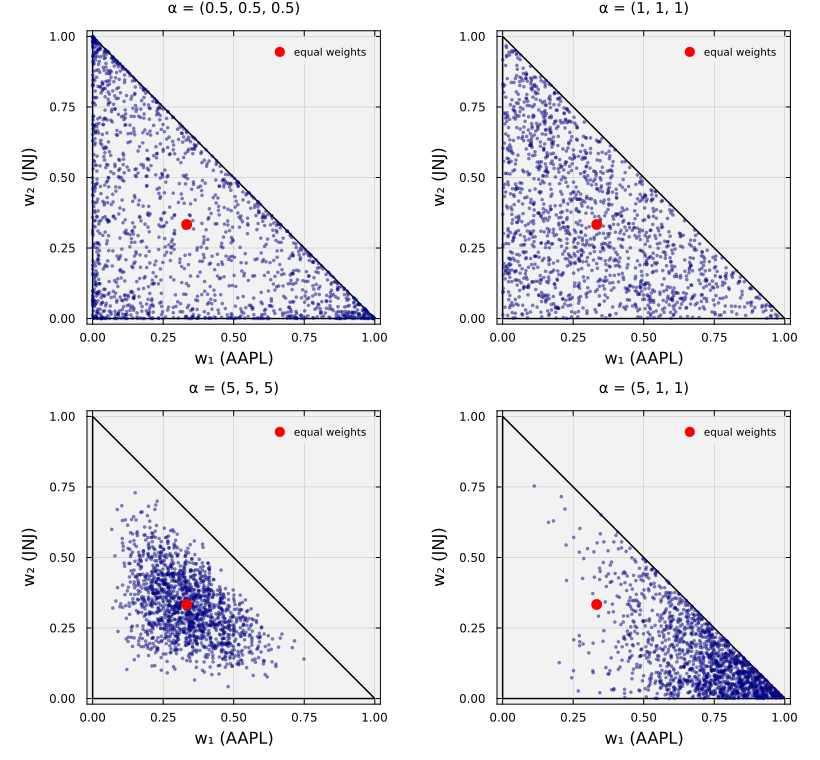

In [8]:
let
    order = ["α = (0.5, 0.5, 0.5)", "α = (1, 1, 1)", "α = (5, 5, 5)", "α = (5, 1, 1)"];
    panels = [];
    for label ∈ order
        W = dirichlet_samples[label];
        p = plot([0, 1, 0, 0], [0, 0, 1, 0]; color=:black, lw=1.5, label="", title=label, titlefontsize=10,
            xlabel="w₁ ($(my_tickers_3[1]))", ylabel="w₂ ($(my_tickers_3[2]))", xlims=(-0.02, 1.02), ylims=(-0.02, 1.02), aspect_ratio=:equal)
        scatter!(p, W[1, 1:1500], W[2, 1:1500]; ms=2, msw=0, alpha=0.5, color=:navy, label="")
        scatter!(p, [1/3], [1/3]; ms=6, color=:red, msw=0, label="equal weights")
        push!(panels, p)
    end
    plot(panels...; layout=(2,2), size=(820, 760), legend=:topright, legendfontsize=7,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent)
end

Small concentrations put many draws near the edges and corners (allocations concentrated in one or two assets); $\alpha_{i}=1$ has constant density over the triangle; large concentrations cluster near equal weights; and the tilted vector pulls the cloud toward the $w_{1}$ corner. Let's verify the lecture's moment formulas, $\mathbb{E}[W_{i}]=\alpha_{i}/\alpha_{0}$ and $\text{Var}(W_{i})=\alpha_{i}(\alpha_{0}-\alpha_{i})/(\alpha_{0}^{2}(\alpha_{0}+1))$, against the tilted sample in the `moment_table::DataFrame` variable:

In [9]:
moment_table = let
    α = [5.0, 1.0, 1.0]; α₀ = sum(α);
    W = dirichlet_samples["α = (5, 1, 1)"];
    df = DataFrame(asset = String[], sample_mean = Float64[], formula_mean = Float64[], sample_var = Float64[], formula_var = Float64[]);
    for i ∈ 1:3
        push!(df, (my_tickers_3[i], mean(W[i,:]), α[i]/α₀, var(W[i,:]), α[i]*(α₀ - α[i])/(α₀^2*(α₀ + 1))));
    end
    df
end
pretty_table(moment_table; formatters = [fmt__printf("%.4f", [2,3,4,5])])

┌────────┬─────────────┬──────────────┬────────────┬─────────────┐
│  asset │ sample_mean │ formula_mean │ sample_var │ formula_var │
│ String │     Float64 │      Float64 │    Float64 │     Float64 │
├────────┼─────────────┼──────────────┼────────────┼─────────────┤
│   AAPL │      0.7127 │       0.7143 │     0.0255 │      0.0255 │
│    JNJ │      0.1436 │       0.1429 │     0.0156 │      0.0153 │
│    XOM │      0.1437 │       0.1429 │     0.0150 │      0.0153 │
└────────┴─────────────┴──────────────┴────────────┴─────────────┘


The sample moments match the formulas to sampling error. Notice the negative dependence the lecture mentioned: with $\alpha_{1}$ large, whenever $w_{1}$ comes out big the other two must come out small, because the three compete for the same unit of wealth.

___

## Task 2: Explore Portfolio Growth and Risk Across the Simplex
In this task, we attach estimated growth and risk to random five-asset allocations and compare sampled candidates with simple reference portfolios.

Now let's attach an objective to the draws. As in the lecture, we use $g_{p}=\mathbf{w}^{\top}\mathbf{g}$ as a deliberate linear one-period proxy, first order in the realized asset log returns rather than an exact portfolio log-growth rate (buy-and-hold wealth over many periods, in Task 3, is a different object). For the five-asset portfolio, we compute the sample-mean growth rate vector $\mathbf{g}^{\prime}$ and the empirical growth-rate covariance $\hat{\mathbf{\Sigma}}_{g}$ from the training data (the covariance example, in miniature), and then for each random weight vector $\mathbf{w}$ the portfolio growth rate's sample mean and standard deviation:
$$
g^{\prime}_{p}(\mathbf{w}) = \mathbf{w}^{\top}\mathbf{g}^{\prime},\qquad
\sigma_{g,p}(\mathbf{w}) = \sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g}\mathbf{w}},
$$
both in units of inverse years (growth-rate units, not volatility: the volatility would be $\sigma_{g,p}\sqrt{\Delta{t}}$). Positive semidefiniteness of $\hat{\mathbf{\Sigma}}_{g}$ is what guarantees the square root exists for every $\mathbf{w}$. Let's compute $\mathbf{g}^{\prime}$ and $\hat{\mathbf{\Sigma}}_{g}$ for the five firms, stored in the `g_mean_5::Vector{Float64}` and `Σ̂_5::Matrix{Float64}` variables:

In [10]:
g_mean_5, Σ̂_5 = let
    G = log_growth_matrix(dataset, my_tickers_5); # growth rates, N × 5
    g_mean = mean(G, dims=1) |> vec;
    Σ = cov(G, dims=1); # growth-rate covariance, 1/yr²
    @assert isapprox(Σ, Σ'; atol=1e-10) && all(eigvals(Symmetric(Σ)) .>= -1e-10) # symmetric, positive semidefinite
    (g_mean, Σ)
end;
pretty_table(DataFrame(ticker = my_tickers_5, mean_growth = g_mean_5, growth_std = sqrt.(diag(Σ̂_5)), volatility = sqrt.(Δt .* diag(Σ̂_5)));
    formatters = [fmt__printf("%.3f", [2,3,4])])

┌────────┬─────────────┬────────────┬────────────┐
│ ticker │ mean_growth │ growth_std │ volatility │
│ String │     Float64 │    Float64 │    Float64 │
├────────┼─────────────┼────────────┼────────────┤
│   AAPL │       0.233 │      3.723 │      0.235 │
│    JNJ │       0.041 │      2.441 │      0.154 │
│    XOM │       0.007 │      3.812 │      0.240 │
│    JPM │       0.128 │      3.719 │      0.234 │
│   NVDA │       0.532 │      6.169 │      0.389 │
└────────┴─────────────┴────────────┴────────────┘


Now let's draw `number_of_samples` uniform ($\alpha_{i}=1$) weight vectors on the five-asset simplex, evaluate $g^{\prime}_{p}$ and $\sigma_{g,p}$ for each, and store them in the `cloud_df::DataFrame` variable (one row per draw, weights included):

In [11]:
cloud_df = let
    d = Dirichlet(ones(length(my_tickers_5)));
    W = rand(d, number_of_samples);
    df = DataFrame(g_p = Float64[], σ_gp = Float64[], w = Vector{Float64}[]);
    for k ∈ 1:number_of_samples
        w = W[:,k];
        push!(df, (dot(w, g_mean_5), sqrt(dot(w, Σ̂_5*w)), w));
    end
    df
end;
first(cloud_df, 3)

Row,g_p,σ_gp,w
,Float64,Float64,Array…
1,0.21056,2.86947,"[0.351807, 0.114215, 0.0911312, 0.27817, 0.164677]"
2,0.362159,4.17428,"[0.0310007, 0.271027, 0.000614541, 0.0679092, 0.629448]"
3,0.281034,3.42853,"[0.327983, 0.102553, 0.191179, 0.00548486, 0.3728]"


Let's plot the cloud in the (risk, growth) plane, and mark the five single-asset portfolios (the corners of the simplex), the equal-weight portfolio, and the lowest-variance draw:

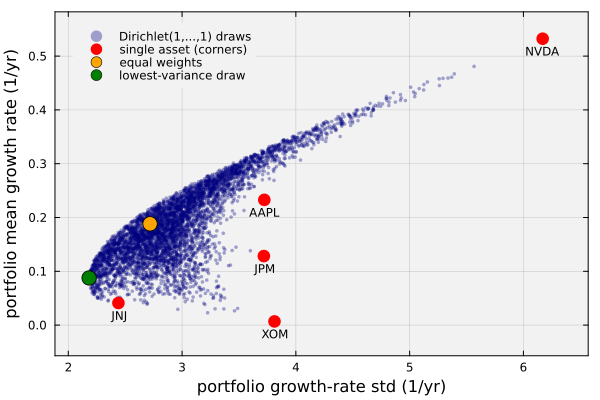

In [12]:
let
    scatter(cloud_df.σ_gp, cloud_df.g_p; ms=2, msw=0, alpha=0.35, color=:navy, label="Dirichlet(1,...,1) draws",
        xlabel="portfolio growth-rate std (1/yr)", ylabel="portfolio mean growth rate (1/yr)")
    σ_single = sqrt.(diag(Σ̂_5)); # single-asset portfolios
    scatter!(σ_single, g_mean_5; ms=7, color=:red, msw=0, label="single asset (corners)")
    for i ∈ eachindex(my_tickers_5)
        annotate!(σ_single[i], g_mean_5[i] - 0.012, text(my_tickers_5[i], 8, :top))
    end
    plot!(xlims=(minimum(cloud_df.σ_gp) - 0.3, maximum(σ_single) + 0.4), ylims=(minimum(cloud_df.g_p) - 0.08, maximum(g_mean_5) + 0.05))
    w_eq = fill(1/length(my_tickers_5), length(my_tickers_5));
    scatter!([sqrt(dot(w_eq, Σ̂_5*w_eq))], [dot(w_eq, g_mean_5)]; ms=8, color=:orange, msw=1, label="equal weights")
    kmin = argmin(cloud_df.σ_gp);
    scatter!([cloud_df.σ_gp[kmin]], [cloud_df.g_p[kmin]]; ms=8, color=:green, msw=1, label="lowest-variance draw")
    plot!(bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent, legend=:topleft)
end

So what do we see? The sampled cloud has a curved left envelope: no random combination reached below a certain risk at a given growth, and the envelope bends. For each allocation, portfolio risk is no larger than the weighted average of the individual risks, so diversification moves the plotted point left of the corresponding weighted-average point in the convex hull when correlations are below one; the equal-weight portfolio has less risk than most of its constituents, and the lowest-variance draw less still. Let's print the lowest-variance draw and compare with the least risky single asset:

In [13]:
let
    kmin = argmin(cloud_df.σ_gp);
    w_min = cloud_df.w[kmin];
    i_single = argmin(sqrt.(diag(Σ̂_5)));
    println("Lowest-variance draw: growth-rate std = $(round(cloud_df.σ_gp[kmin], digits=3)) 1/yr, mean growth rate = $(round(cloud_df.g_p[kmin], digits=3)) 1/yr")
    pretty_table(DataFrame(ticker = my_tickers_5, weight = w_min); formatters = [fmt__printf("%.3f", [2])])
    println("Least risky single asset: $(my_tickers_5[i_single]) with growth-rate std = $(round(sqrt(Σ̂_5[i_single,i_single]), digits=3)) 1/yr")
end

Lowest-variance draw: growth-rate std = 2.183 1/yr, mean growth rate = 0.088 1/yr
┌────────┬─────────┐
│ ticker │  weight │
│ String │ Float64 │
├────────┼─────────┤
│   AAPL │   0.163 │
│    JNJ │   0.592 │
│    XOM │   0.118 │
│    JPM │   0.108 │
│   NVDA │   0.020 │
└────────┴─────────┘
Least risky single asset: JNJ with growth-rate std = 2.441 1/yr


The lowest-variance draw is only the best of `number_of_samples` random guesses. It is by definition the leftmost sampled point, but it need not lie on the true minimum-variance frontier of all feasible weights, and a different seed would give a slightly different answer. The point that is exactly on that frontier, the minimum-variance portfolio, is what L5b computes by solving an optimization problem instead of sampling. That is the lecture's distinction in a picture: sampling explores, optimization finds.

___

## Task 3: Buy-and-Hold Wealth and Weight Drift
In this task, we convert selected weights into share counts, follow buy-and-hold wealth over the final 252 trading days of the training data, and measure the resulting weight drift.

Finally, let's turn weights into a portfolio and hold it. With an initial budget $W_{0}$ and weights $\mathbf{w}$, we buy $n_{i}=w_{i}W_{0}/S_{i}(0)$ shares of each asset at the start of the final 252 trading days in the training data and hold them, so wealth is $W_{t}=\sum_{i}n_{i}S_{i}(t)$. Let's compute the wealth path over that year for the equal-weight portfolio, the lowest-variance draw from Task 2, and three more uniform Dirichlet draws, using the volume-weighted average price. We store the paths in the `wealth_df::DataFrame` variable (one column per portfolio):

In [14]:
wealth_df, holdings = let
    W₀ = 10_000.0; # initial budget (USD)
    n_days = 252; # last trading year of the training data
    prices = hcat([dataset[t][end-n_days+1:end, :volume_weighted_average_price] for t ∈ my_tickers_5]...); # n_days × 5
    portfolios = Dict{String, Vector{Float64}}();
    portfolios["equal weights"] = fill(1/5, 5);
    portfolios["lowest-variance draw"] = cloud_df.w[argmin(cloud_df.σ_gp)];
    d = Dirichlet(ones(5)); rng_draws = rand(d, 3);
    for k ∈ 1:3
        portfolios["Dirichlet draw $(k)"] = rng_draws[:,k];
    end
    df = DataFrame(day = 1:n_days);
    holdings = Dict{String, Vector{Float64}}();
    for (label, w) ∈ portfolios
        n = w .* W₀ ./ prices[1,:]; # shares bought at the start
        holdings[label] = n;
        df[!, label] = prices*n ./ W₀; # W_t / W_0
    end
    (df, holdings)
end;
first(wealth_df, 3)

Row,day,equal weights,lowest-variance draw,Dirichlet draw 1,Dirichlet draw 3,Dirichlet draw 2
,Int64,Float64,Float64,Float64,Float64,Float64
1,1,1.0,1.0,1.0,1.0,1.0
2,2,0.999522,1.00336,0.995984,0.996376,0.996724
3,3,0.999252,1.00159,0.998534,0.992535,0.99208


Let's plot the wealth paths relative to the initial budget:

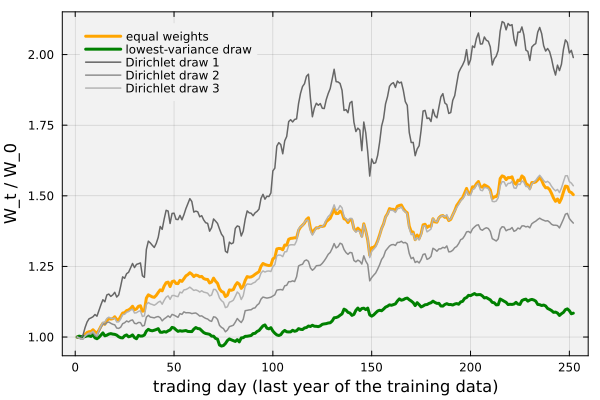

In [15]:
let
    labels = ["equal weights", "lowest-variance draw", "Dirichlet draw 1", "Dirichlet draw 2", "Dirichlet draw 3"];
    colors = [:orange, :green, :gray40, :gray55, :gray70];
    p = plot(xlabel="trading day (last year of the training data)", ylabel="W_t / W_0", legend=:topleft)
    for (label, c) ∈ zip(labels, colors)
        plot!(p, wealth_df.day, wealth_df[!, label]; lw=(startswith(label,"Dirichlet") ? 1.5 : 3), color=c, label=label)
    end
    plot!(p, bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent)
end

The wealth paths differ because the initial allocations differ. The plot also shows that a buy-and-hold portfolio does not keep its weights. Let's compare the initial weights of the equal-weight portfolio with the fractions of wealth in each asset at the end of the year, $w_{i}(T)=n_{i}S_{i}(T)/W_{T}$, in the `drift_table::DataFrame` variable:

In [16]:
drift_table = let
    n_days = 252;
    prices_end = [dataset[t][end, :volume_weighted_average_price] for t ∈ my_tickers_5];
    n = holdings["equal weights"];
    W_T = dot(n, prices_end);
    DataFrame(ticker = my_tickers_5, initial_weight = fill(0.2, 5), final_weight = n .* prices_end ./ W_T)
end
pretty_table(drift_table; formatters = [fmt__printf("%.3f", [2,3])])

┌────────┬────────────────┬──────────────┐
│ ticker │ initial_weight │ final_weight │
│ String │        Float64 │      Float64 │
├────────┼────────────────┼──────────────┤
│   AAPL │          0.200 │        0.179 │
│    JNJ │          0.200 │        0.120 │
│    XOM │          0.200 │        0.140 │
│    JPM │          0.200 │        0.186 │
│   NVDA │          0.200 │        0.375 │
└────────┴────────────────┴──────────────┘


The winners of the year end up with a larger share of the portfolio and the laggards with a smaller one; the equal-weight portfolio is equal-weight only on day one. Holding constant weights would require selling winners and buying laggards, that is, rebalancing, which is a different strategy with its own trading costs.

___

## Summary
In this example, we sampled long-only portfolio weights with the Dirichlet distribution, used the samples to explore the growth and risk of random portfolios, and held a few of them for a year.

> __Key Takeaways:__
>
> * **The concentration vector is the dial:** Symmetric concentrations below one favor sparse portfolios near the edges, large ones cluster near equal weights, and unequal concentrations tilt the draws toward chosen assets; every draw is a valid long-only allocation, and the sample moments match the lecture's formulas.
>
> * **Random portfolios trace the shape of the risk-growth trade-off:** The cloud of Dirichlet draws has a curved left envelope. When correlations are below one, a combination's risk lies to the left of the corresponding weighted-average risk point for its constituents. The lowest-variance draw is only an approximation of the minimum-variance portfolio that L5b will compute exactly.
>
> * **Buy-and-hold weights drift:** Wealth is a weighted sum of price ratios, and as prices move the fractions of wealth in each asset move away from the initial weights, so constant weights require rebalancing.

Sampling the simplex is a good way to see what portfolios can do; choosing among them is an optimization problem, which is where the course goes next.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
